# Q4 Bound states of a quantum particle

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [57]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Helper functions (from BVP-and-Eigenvalue-problems notebook)
# ============================================================

# Standard RK4 integrator — f(x, y, k) where k is a parameter (here energy E)
def rk4(f, x, y, k, h):
    k1 = h * f(x, y, k)
    k2 = h * f(x + h/2, y + k1/2, k)
    k3 = h * f(x + h/2, y + k2/2, k)
    k4 = h * f(x + h, y + k3, k)
    return y + (k1 + 2*k2 + 2*k3 + k4) / 6

# Caller: integrates ODE from xlim[0] to xlim[1] with N points
def caller_rk4(f, xlim, yini, k, N):
    x1, x2 = xlim
    xs = np.linspace(x1, x2, N)
    h = xs[1] - xs[0]
    y = yini
    ys = np.zeros((N, len(yini)))
    for i in range(N):
        ys[i] = np.array(y)
        y = rk4(f, xs[i], y, k, h)
    return xs, ys

# Secant method for root-finding
def secant(ks, f, method, ybound):
    k1, k2 = ks
    it = 0
    while abs(method(k2, f, ybound)) > tol and it < maxiter:
        f1 = method(k1, f, ybound)
        f2 = method(k2, f, ybound)
        if abs(f2 - f1) < 1e-15:
            break
        k1, k2 = k2, (f2 * k1 - f1 * k2) / (f2 - f1)
        it += 1
    if it == maxiter:
        return it, None
    else:
        return it, k2

# BISECTION method for root-finding    
def bisection(ks, f, method, ybound, eps=1.0e-6):
    k1, k2 = ks
    f1 = method(k1, f, ybound)
    f2 = method(k2, f, ybound)
    if f1*f2 > 0:
        print("invalid Range")
        return None
    elif f1== 0 or f2 == 0:
        print("input point is a root")
        return f1 if f1 == 0 else f2
    else: 
        i = 0
        C = (k1+k2)/2
        while abs(method(C, f, ybound)) > eps and i < maxiter:
            f1 = method(k1, f, ybound)
            f2 = method(k2, f, ybound)
            if f1 * f2 < 0:
                k2 = C
            else:
                k1 = C
            C = (k2 + k1) / 2
            i += 1
    if i == maxiter and method(C, f, ybound) > eps:
        return i, C
    return i, C

# Simpson's 1/3 rule for normalization integral
def simp13(y, h):
    store = y[0]**2 + y[-1]**2
    for i in range(2, len(y)):
        if i % 2 == 0:
            store += 4 * y[i]**2
        else:
            store += 2 * y[i]**2
    return store * (h / 3)

# trapizoidal rule for normalization integral
def int_trap(y,h):
    # The sum of interior points (indices 1 to N-1) multiplied by 2, 
    # plus the endpoints (indices 0 and N) multiplied by 1.
    integral = (h / 2) * (y[0] + 2 * np.sum(y[1:-1]) + y[-1])
    return integral

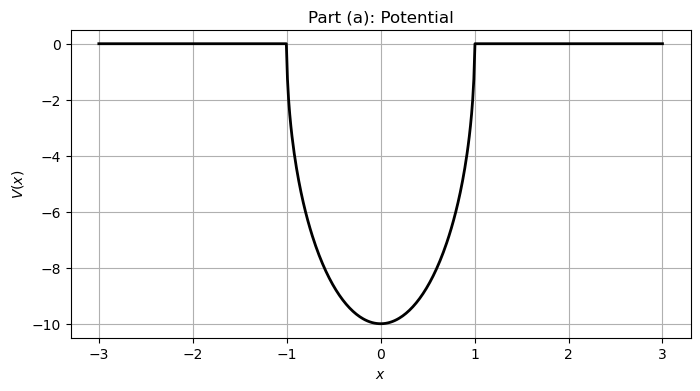

In [52]:
Vo = 10.0
a = 1.0

def pot_a(x):
    if abs(x) > a:
        return 0.0
    else:
        return -Vo * ((a**2-x**2)**(0.5))

def odefun_a(x, y, E):
    """RHS of Schrödinger equation for potential (a)"""
    k2 = E - pot_a(x)
    return np.array([y[1], -k2 * y[0]])

def score_a(E, f, ybound):
    """Two-sided shooting: derivative mismatch at matching point x_m = -1"""
    xm = 0.5
    # psi_< : integrate from left boundary
    yini1 = (ybound[0], 1.0e-3)#∆x = 10−3.
    xs1, ys1 = caller_rk4(f, xlim, yini1, E, N)
    a = abs(xs1 - xm)
    n1 = np.where(a == np.min(a))[0][0]
    # psi_> : integrate from right boundary
    yini2 = (ybound[1], 1.0e-3)#∆x = 10−3.
    xs2, ys2 = caller_rk4(f, xlim[-1::-1], yini2, E, N)
    a = abs(xs2 - xm)
    n2 = np.where(a == np.min(a))[0][0]
    # Scale psi_> so that psi_<(xm) = psi_>(xm)
    if abs(ys2[n2][0]) < 1e-6:
        return 1e10
    ys2 = ys1[n1][0] * ys2 / ys2[n2][0]
    # Return derivative mismatch
    return ys1[n1][1] - ys2[n2][1]

# Parameters
xlim = (-3.0, 3.0)
ybound = (0.0, 0.0)
N = 257
h = (xlim[-1]-xlim[0])/N
maxiter = 100
tol = 1.0e-8

# Quick plot of the potential
xs_pot = np.linspace(-3, 3, 500)
Vx = np.array([pot_a(x) for x in xs_pot])
plt.figure(figsize=(8, 4))
plt.plot(xs_pot, Vx, 'k-', linewidth=2)
plt.xlabel('$x$'); plt.ylabel('$V(x)$')
plt.title('Part (a): Potential')
plt.grid(True); plt.show()

In [39]:
# Scan energy range to locate eigenvalues (sign changes in the score)
Es_a = np.linspace(-Vo, -0.1, 1000) 
scores_a = [score_a(E, odefun_a, ybound) for E in Es_a]

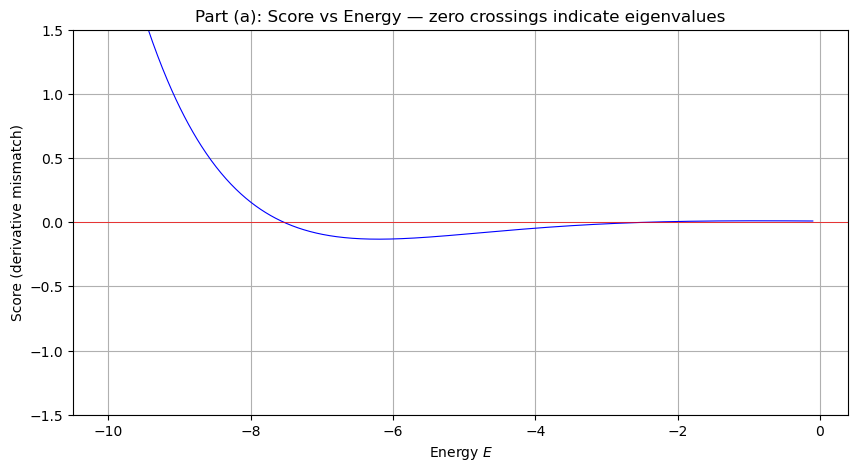

In [40]:
plt.figure(figsize=(10, 5))
plt.plot(Es_a, scores_a, 'b-', linewidth=0.8)
plt.ylim([-1.5, 1.5])
plt.grid(True)
plt.xlabel("Energy $E$")
plt.ylabel("Score (derivative mismatch)")
plt.title("Part (a): Score vs Energy — zero crossings indicate eigenvalues")
plt.axhline(y=0, color='r', linewidth=0.5)
plt.show()

In [43]:
scores_arr = np.array(scores_a)
sign_changes_a = []
for i in range(len(scores_arr) - 1):
    if abs(scores_arr[i]) < 100 and abs(scores_arr[i+1]) < 100:  # skip divergences
        if scores_arr[i] * scores_arr[i+1] < 0:
            sign_changes_a.append((Es_a[i], Es_a[i+1]))

print(f"Detected {len(sign_changes_a)} sign changes (potential eigenvalues):\n")
# detect sign changes and find eigenvalues using bisection method
eigenvalues_a = []
for i, (e1, e2) in enumerate(sign_changes_a):
    it, Eeigen = bisection((e1, e2), odefun_a, score_a, ybound)
    if Eeigen is not None:
        eigenvalues_a.append(Eeigen)
        print(f"  E_{i} = {Eeigen:.6f}  (converged in {it} iterations)")
    else:
        print(f"  E_{i} in ({e1:.2f}, {e2:.2f}) — did not converge")

print(f"Bound state eigenvalues: {[f'{E:.6f}' for E in eigenvalues_a]}")

Detected 2 sign changes (potential eigenvalues):

  E_0 = -7.533488  (converged in 2 iterations)
  E_1 = -2.423022  (converged in 2 iterations)
Bound state eigenvalues: ['-7.533488', '-2.423022']


[1.0409692552393324e-09, 3.2806680289043655e-10]


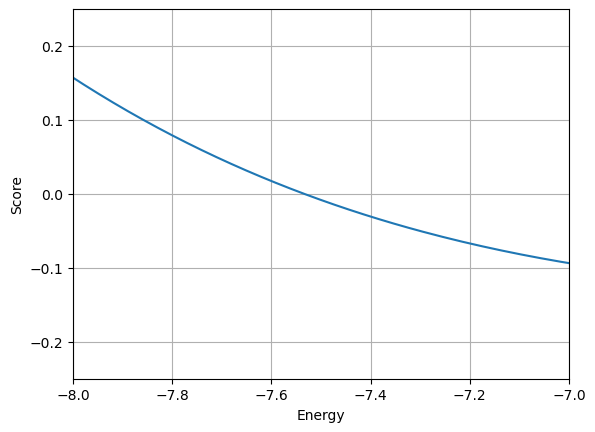

In [44]:
plt.plot(Es_a,scores_a);
plt.grid()
plt.xlabel("Energy");
plt.ylabel("Score");
plt.ylim([-0.25, 0.25])
plt.xlim([-8,-7])

#confirming the eigen valuesare within tolorance
score_eigenE = [abs(score_a(E, odefun_a, ybound))for E in eigenvalues_a]
print(score_eigenE)

In [74]:
Eeigen = eigenvalues_a[0]
yini = (ybound[0], 0.1)# 1.0e-2 is an arbitrary number finally adjusted by normalization
xs, ys = caller_rk4(odefun_a, xlim, yini, Eeigen, N);
y1 = [y[0] for y in ys];

In [75]:
int_t = int_trap(y1,h)

print(int_t)

26.30355246978293


Text(0, 0.5, '$\\psi$')

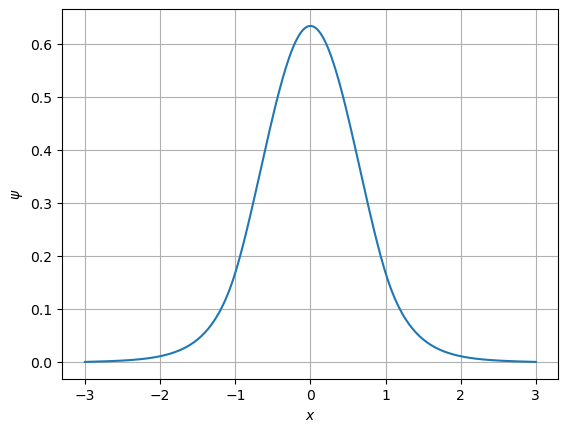

In [76]:
y1n = (1/int_t)*(np.array(y1))
plt.plot(xs, y1n);
plt.grid();
plt.xlabel("$x$")
plt.ylabel("$\\psi$")

In [77]:
Eeigen = eigenvalues_a[1]
yini = (ybound[0], 0.1)# 1.0e-2 is an arbitrary number finally adjusted by normalization
xs, ys = caller_rk4(odefun_a, xlim, yini, Eeigen, N);
y2 = [y[0] for y in ys];

In [92]:
int_t = int_trap(y2,h)

print(int_t)

1.6028283180511895


Text(0, 0.5, '$\\psi$')

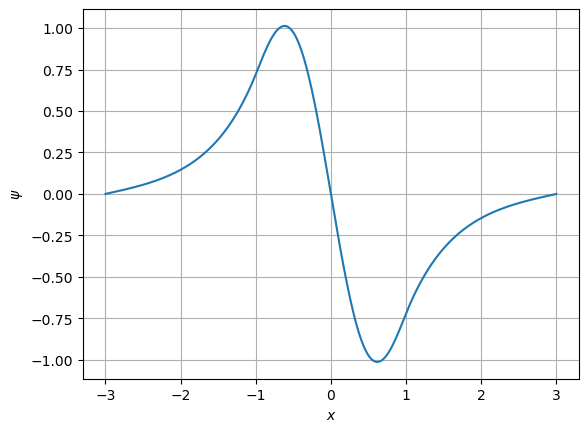

In [93]:
y2n = (1/int_t)*(np.array(y2))
plt.plot(xs, y2);
plt.grid();
plt.xlabel("$x$")
plt.ylabel("$\\psi$")

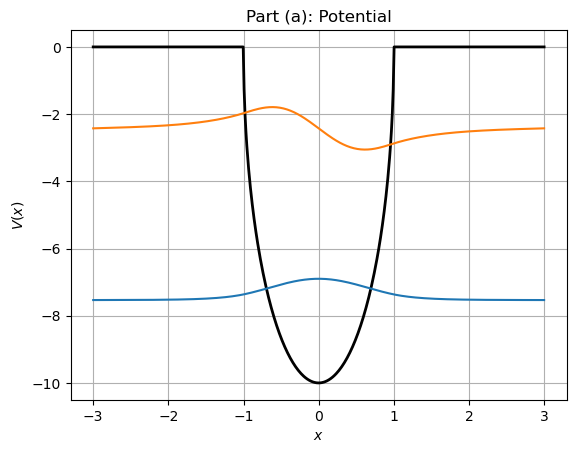

In [94]:
#d (iii)

y1nE = eigenvalues_a[0]+y1n
y2nE = eigenvalues_a[1]+y2n
xs_pot = np.linspace(-3, 3, 500)
Vx = np.array([pot_a(x) for x in xs_pot])
plt.plot(xs_pot, Vx, 'k-', linewidth=2)
plt.plot(xs, y1nE);
plt.plot(xs, y2nE);
plt.xlabel('$x$'); plt.ylabel('$V(x)$')
plt.title('Part (a): Potential')
plt.grid(True); plt.show()